# PRISM Average Daily Mean Temperature — 1991-2020 Normals


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
import sys
sys.path.append('..')
from efgpnd import EFGPND
from load_prism import load_prism_dataset_torch
from utils.ski import fit_ski_gp


In [14]:
DATASET_DIRNAME = 'prism_tmean_us_30s_2020_avg_30y'

# Load data
# x, y = load_prism_dataset_torch(DATASET_DIRNAME, n_sub=50_000)
x, y = load_prism_dataset_torch(DATASET_DIRNAME,n_sub = 100_000)
# x, y = load_prism_dataset_torch(DATASET_DIRNAME)
print(f"x shape: {x.shape}")  # (N, 2) — lon, lat
print(f"y shape: {y.shape}")  # (N,) — mean temperature (°C)
print(f"Lon range: {x[:,0].min():.4f} to {x[:,0].max():.4f}")
print(f"Lat range: {x[:,1].min():.4f} to {x[:,1].max():.4f}")
print(f"Temp range: {y.min():.1f} to {y.max():.1f} °C")


x shape: torch.Size([100000, 2])
y shape: torch.Size([100000])
Lon range: -124.7667 to -66.9750
Lat range: 24.5250 to 49.4167
Temp range: -6.8 to 25.7 °C


In [15]:
# # Plot raw data
# fig, ax = plt.subplots(figsize=(12, 6))
# sc = ax.scatter(x[:,0].numpy(), x[:,1].numpy(), c=y.numpy(), s=0.3,
#                 cmap='RdYlBu_r', alpha=0.7, rasterized=True)
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# ax.set_title('PRISM Average Daily Mean Temperature (°C) — 50k subsample')
# plt.colorbar(sc, ax=ax, label='Temperature (°C)')
# ax.set_aspect(1.3)
# plt.tight_layout()


In [16]:
# Normalize inputs to [0, 1] and standardize outputs
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f"x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}")
print(f"y mean={y.mean():.4f}, std={y.std():.4f}")


x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=0.0000, std=1.0000


In [17]:
EPSILON = 1e-5
kernel_type = 'SE'
cg_tol = 1e-5
noise_floor = 1e-6


In [18]:
max_iters = 50
J = 1

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
    'mean_cg_iters': [],
    'trace_cg_iters': [],
    'mtot': [],
    'feature_count': [],
}

model = EFGPND(x, y, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.05)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor)
    optimizer.step()

    stats = model.last_gradient_stats
    mean_cg_iters = stats.get('mean_cg_iters')
    trace_cg_iters = stats.get('trace_cg_iters')
    mtot = stats.get('mtot')
    feature_count = stats.get('feature_count')

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(mean_cg_iters)
    training_log['trace_cg_iters'].append(trace_cg_iters)
    training_log['mtot'].append(mtot)
    training_log['feature_count'].append(feature_count)

    if it % 10 == 0:
        print(
            f"iter {it:>3}  ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}  "
            f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}  mtot={mtot}  M={feature_count}"
        )

print(
    f"Final: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}, "
    f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}, mtot={mtot}, M={feature_count}"
)


iter   0  ℓ=0.1927  σ_f²=1.051  σ_n²=0.1902  cg(mean/trace)=409/316  mtot=17  M=289
iter  10  ℓ=0.1167  σ_f²=1.728  σ_n²=0.116  cg(mean/trace)=344/254  mtot=23  M=529
iter  20  ℓ=0.07075  σ_f²=2.808  σ_n²=0.07361  cg(mean/trace)=631/286  mtot=33  M=1089
iter  30  ℓ=0.03999  σ_f²=4.816  σ_n²=0.04879  cg(mean/trace)=541/284  mtot=51  M=2601
iter  40  ℓ=0.02286  σ_f²=7.859  σ_n²=0.03201  cg(mean/trace)=455/267  mtot=83  M=6889
Final: ℓ=0.01529, σ_f²=9.544, σ_n²=0.02183, cg(mean/trace)=372/284, mtot=123, M=15129


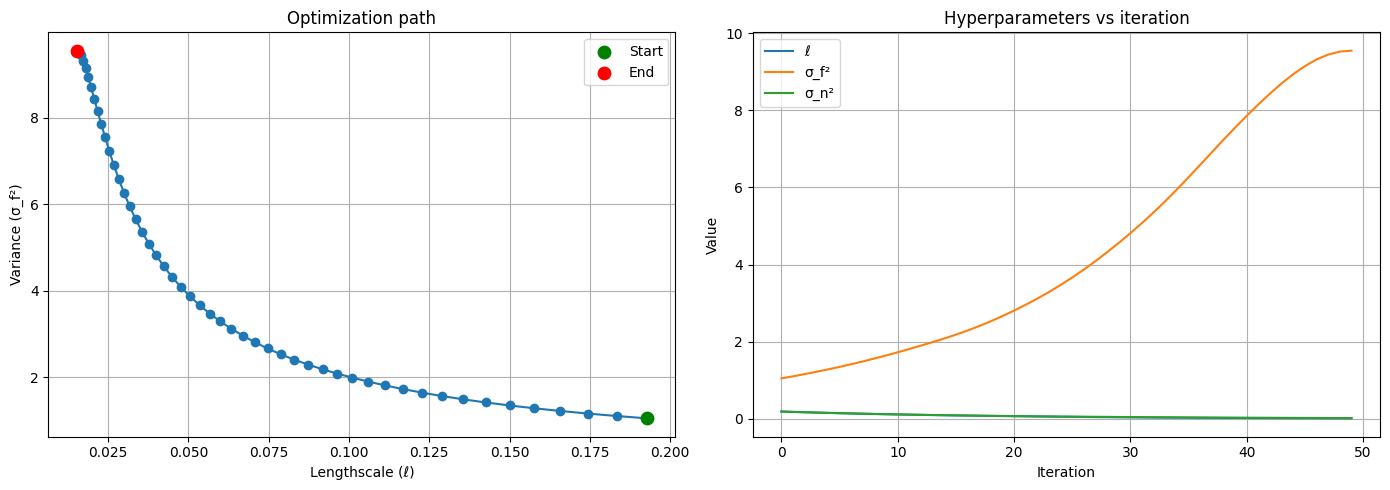

In [25]:
# Plot optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ℓ)')
ax1.set_ylabel('Variance (σ_f²)')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='ℓ')
ax2.plot(training_log['iter'], training_log['variance'], label='σ_f²')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='σ_n²')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


## SKI Benchmark
Fit a memory-controlled GPyTorch SKI baseline. If the helper subsamples, reuse `x_ski_benchmark` and `y_ski_benchmark` for a matched EFGPND-vs-SKI timing or accuracy comparison.

In [20]:
SKI_MAX_TRAIN_N = 150_000
SKI_MAX_ITERS = 2
SKI_GRID_SIZE = (288, 128)
SKI_LR = 0.05


In [21]:
ski_result = fit_ski_gp(
    x,
    y,
    kernel=kernel_type,
    grid_size=SKI_GRID_SIZE,
    max_iters=SKI_MAX_ITERS,
    lr=SKI_LR,
    noise_floor=noise_floor,
    max_train_n=SKI_MAX_TRAIN_N,
    subsample_seed=0,
    cg_tolerance=1e-3,
    max_cg_iterations=100,
    max_preconditioner_size=10,
    max_lanczos_quadrature_iterations=10,
    num_trace_samples=2,
    use_toeplitz=True,
    memory_efficient=True,
    verbose=True,
)

ski_history = ski_result['history']
ski_train_indices = ski_result['train_indices']
if ski_train_indices is None:
    x_ski_benchmark = x
    y_ski_benchmark = y
else:
    ski_train_indices_device = ski_train_indices.to(x.device)
    x_ski_benchmark = x.index_select(0, ski_train_indices_device)
    y_ski_benchmark = y.index_select(0, ski_train_indices_device)

ski_iter_sec = np.array(ski_history['forward_sec']) + np.array(ski_history['backward_sec'])
print(f"SKI benchmark points: {ski_result['num_train']:,} / {ski_result['num_total']:,}")
print(f"SKI grid size: {ski_result['grid_size']}")
print(f"SKI best loss: {ski_result['best_loss']:.6f} at iter {ski_result['best_iteration']}")
print(f"Mean SKI hyper-step time: {ski_iter_sec.mean():.2f}s")
print('Use x_ski_benchmark and y_ski_benchmark for a matched EFGPND-vs-SKI rerun.')


[SKI] iter   1/2  loss=1.38286  ls=0.66846  os=0.718459  noise=0.718461  time(fwd/bwd)=7.21/13.49s  rss=0.330 GB
[SKI] iter   2/2  loss=1.37759  ls=0.644689  os=0.744084  noise=0.744165  time(fwd/bwd)=5.48/9.06s  rss=0.351 GB
SKI benchmark points: 100,000 / 100,000
SKI grid size: (288, 128)
SKI best loss: 1.377591 at iter 2
Mean SKI hyper-step time: 17.62s
Use x_ski_benchmark and y_ski_benchmark for a matched EFGPND-vs-SKI rerun.


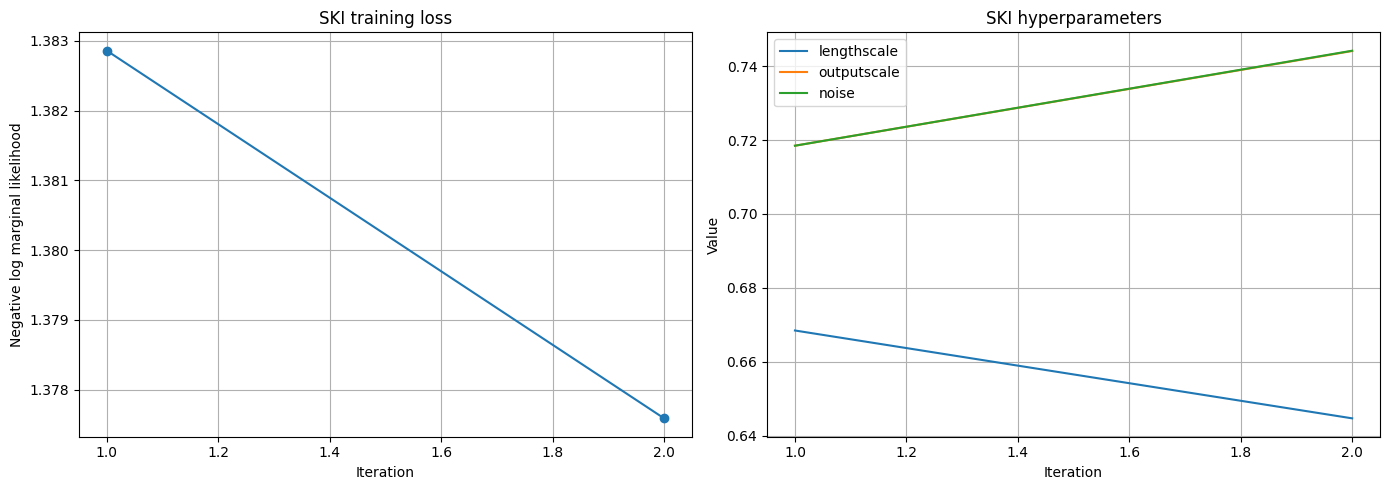

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ski_history['iteration'], ski_history['loss'], 'o-')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Negative log marginal likelihood')
ax1.set_title('SKI training loss')
ax1.grid(True)

ax2.plot(ski_history['iteration'], ski_history['lengthscale'], label='lengthscale')
ax2.plot(ski_history['iteration'], ski_history['outputscale'], label='outputscale')
ax2.plot(ski_history['iteration'], ski_history['noise'], label='noise')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('SKI hyperparameters')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


In [23]:
# Predict posterior mean on a grid
grid_res = 200
g0 = torch.linspace(0, 1, grid_res, dtype=x.dtype)
g1 = torch.linspace(0, 1, grid_res, dtype=x.dtype)
G0, G1 = torch.meshgrid(g0, g1, indexing='ij')
x_new = torch.stack([G0.flatten(), G1.flatten()], dim=1)

mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred

# Inverse transform back to original scales
mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res, grid_res)
lon_grid = (G0.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item())
lat_grid = (G1.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item())


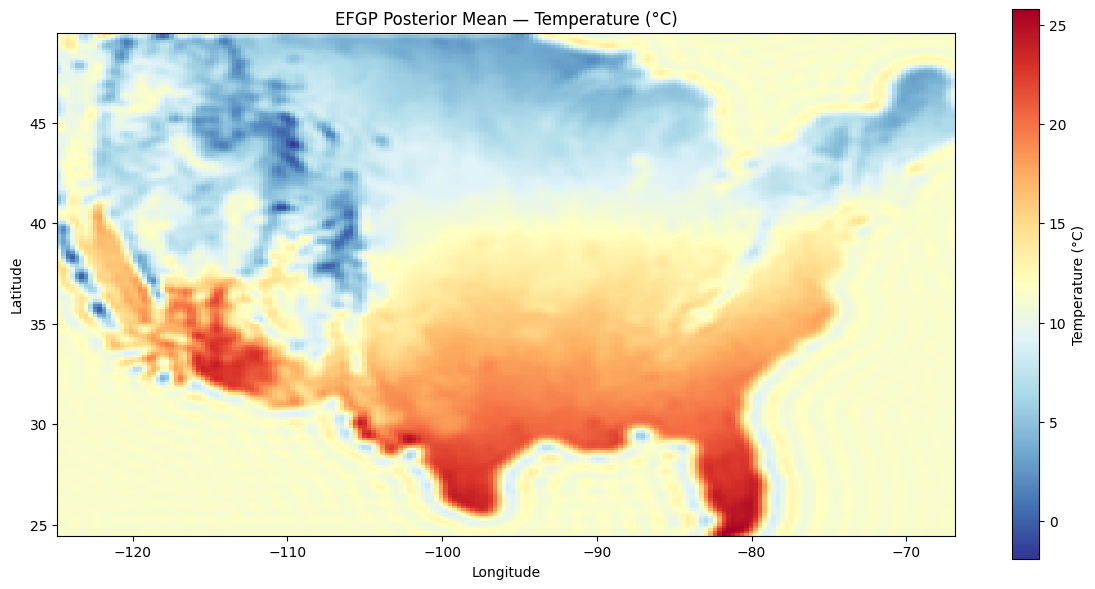

In [24]:
# Plot posterior mean
fig, ax = plt.subplots(figsize=(12, 6))
pcm = ax.pcolormesh(lon_grid, lat_grid, mean_grid, cmap='RdYlBu_r',
                     shading='auto', rasterized=True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('EFGP Posterior Mean — Temperature (°C)')
plt.colorbar(pcm, ax=ax, label='Temperature (°C)')
ax.set_aspect(1.3)
plt.tight_layout()
